# Merging `IxIDN_ORDON_benchmark.csv` with its source datasets

Goal: for every disease pair in the benchmark, determine whether it came from **IxIDN**, **ORDON**, or both, and record the source row it came from.

Final columns:

`ID, d1_disease_label, d2_disease_label, DDA, exist_IxIDN, exist_ORDON, IxIDN_ID, ORDON_ID`

where `IxIDN_ID` / `ORDON_ID` are the **0-based row numbers** in `IxIDN_df.csv` / `ORDON_df.csv` (blank when the pair is not in that source), and `DDA` is joined on `ID` from the DDA scores file.

The DDA input and the output filename are **parameters** (see the next cell) so the same notebook can be run for `_v1`, `_v2`, … without editing. They can be overridden from the shell via the `DDA_FILE` / `MERGED_FILE` environment variables.

Join key: the disease-pair `(d1_disease_label, d2_disease_label)`.

**Important:** the pair orientation is *not* preserved between the benchmark and the source files, so a naive merge on `(d1, d2)` badly under-counts. We therefore join on an **order-insensitive** canonical pair key `tuple(sorted([d1, d2]))`. Both variants are computed below so the difference is visible.

In [1]:
import os
from pathlib import Path

import pandas as pd

RAW = Path.cwd().parent / "raw_benchmarks"
OUT = Path.cwd()

# --- parameters -------------------------------------------------------------
DDA_FILE = os.environ.get("DDA_FILE", "IxIDN_ORDON_benchmark_DDA_v2.csv")
MERGED_FILE = os.environ.get("MERGED_FILE", "IxIDN_ORDON_benchmark_v2_merged.csv")
# ---------------------------------------------------------------------------

print(f"DDA input   : {DDA_FILE}")
print(f"output      : {MERGED_FILE}\n")

benchmark = pd.read_csv(RAW / "IxIDN_ORDON_benchmark.csv")
ixidn = pd.read_csv(RAW / "IxIDN_df.csv")
ordon = pd.read_csv(RAW / "ORDON_df.csv")
dda = pd.read_csv(OUT / DDA_FILE)

for name, df in [("benchmark", benchmark), ("IxIDN", ixidn), ("ORDON", ordon), ("DDA", dda)]:
    print(f"{name:>9}: {df.shape[0]:>6,} rows x {df.shape[1]} cols | {list(df.columns)}")

DDA input   : IxIDN_ORDON_benchmark_DDA_v2.csv
output      : IxIDN_ORDON_benchmark_v2_merged.csv

benchmark: 10,336 rows x 3 cols | ['ID', 'd1_disease_label', 'd2_disease_label']
    IxIDN:  5,336 rows x 6 cols | ['d1_disease_id', 'd1_disease_label', 'd2_disease_id', 'd2_disease_label', 'drug_labels', 'trial_count_total']
    ORDON:  5,000 rows x 5 cols | ['d1_disease_id', 'd1_disease_label', 'd2_disease_id', 'd2_disease_label', 'unique_key']
      DDA: 10,336 rows x 4 cols | ['ID', 'd1_disease_label', 'd2_disease_label', 'DDA']


## 1. Build the join keys and the source row numbers

In [2]:
L1, L2 = "d1_disease_label", "d2_disease_label"


def add_keys(df: pd.DataFrame, row_id=None) -> pd.DataFrame:
    """Attach an ordered key, an order-insensitive pair key, and optionally a row number."""
    df = df.copy()
    a = df[L1].astype("string").str.strip()
    b = df[L2].astype("string").str.strip()
    df["key_ordered"] = a + " || " + b
    lo = a.where(a <= b, b)
    hi = b.where(a <= b, a)
    df["key_pair"] = lo + " || " + hi
    if row_id is not None:
        df[row_id] = range(len(df))  # 0-based row number in the source CSV
    return df


benchmark = add_keys(benchmark)
ixidn = add_keys(ixidn, row_id="IxIDN_ID")
ordon = add_keys(ordon, row_id="ORDON_ID")

print("duplicate pair keys within each file (order-insensitive):")
for name, df in [("benchmark", benchmark), ("IxIDN", ixidn), ("ORDON", ordon)]:
    print(f"  {name:>9}: {df['key_pair'].duplicated().sum():>4}")

assert benchmark["ID"].is_unique and dda["ID"].is_unique, "ID is not a unique key"

duplicate pair keys within each file (order-insensitive):
  benchmark:    2
      IxIDN:    0
      ORDON:    0


## 2. Why orientation matters

Compare how many benchmark rows are found under each key definition.

In [3]:
comparison = pd.DataFrame(
    {
        "ordered (d1,d2) match": [
            benchmark["key_ordered"].isin(set(ixidn["key_ordered"])).sum(),
            benchmark["key_ordered"].isin(set(ordon["key_ordered"])).sum(),
        ],
        "order-insensitive match": [
            benchmark["key_pair"].isin(set(ixidn["key_pair"])).sum(),
            benchmark["key_pair"].isin(set(ordon["key_pair"])).sum(),
        ],
    },
    index=["IxIDN", "ORDON"],
)
comparison["gained by ignoring order"] = (
    comparison["order-insensitive match"] - comparison["ordered (d1,d2) match"]
)
comparison

,"ordered (d1,d2) match",order-insensitive match,gained by ignoring order
IxIDN,2767,5338,2571
ORDON,5002,5002,0


## 3. Merge and flag provenance

Source frames are de-duplicated on `key_pair` first so the merge cannot inflate the benchmark row count (both are already dup-free, so nothing is dropped).

In [4]:
ix_side = ixidn.drop_duplicates("key_pair")[["key_pair", "IxIDN_ID"]]
ord_side = ordon.drop_duplicates("key_pair")[["key_pair", "ORDON_ID"]]

merged = (
    benchmark.merge(dda[["ID", "DDA"]], on="ID", how="left", validate="1:1")
    .merge(ix_side, on="key_pair", how="left", validate="m:1")
    .merge(ord_side, on="key_pair", how="left", validate="m:1")
)

merged["exist_IxIDN"] = merged["IxIDN_ID"].notna()
merged["exist_ORDON"] = merged["ORDON_ID"].notna()

# nullable integer so unmatched rows stay blank rather than becoming 12.0
merged["IxIDN_ID"] = merged["IxIDN_ID"].astype("Int64")
merged["ORDON_ID"] = merged["ORDON_ID"].astype("Int64")

assert len(merged) == len(benchmark), "merge changed the row count"
print(f"merged rows: {len(merged):,} (benchmark rows: {len(benchmark):,})")
print(f"DDA missing: {merged['DDA'].isna().sum()}")

# The DDA file carries its own label columns; confirm they agree with the benchmark
# row-for-row, i.e. that ID really is the same index in both files.
chk = benchmark.merge(dda, on="ID", suffixes=("_b", "_d"))
mismatch = (chk[f"{L1}_b"] != chk[f"{L1}_d"]) | (chk[f"{L2}_b"] != chk[f"{L2}_d"])
print(f"DDA label mismatches vs benchmark on ID: {mismatch.sum()}")

merged rows: 10,336 (benchmark rows: 10,336)
DDA missing: 0
DDA label mismatches vs benchmark on ID: 0


## 4. How many rows merged, and against which dataset?

In [5]:
n = len(merged)
neither = (~merged["exist_IxIDN"] & ~merged["exist_ORDON"]).sum()

summary = pd.DataFrame(
    [
        ("IxIDN only", (merged["exist_IxIDN"] & ~merged["exist_ORDON"]).sum()),
        ("ORDON only", (~merged["exist_IxIDN"] & merged["exist_ORDON"]).sum()),
        ("both", (merged["exist_IxIDN"] & merged["exist_ORDON"]).sum()),
        ("unmatched (neither)", neither),
        ("matched at least one", n - neither),
        ("benchmark total", n),
    ],
    columns=["bucket", "rows"],
)
summary["pct"] = (summary["rows"] / n * 100).round(2)
summary

,bucket,rows,pct
0,IxIDN only,5334,51.61
1,ORDON only,4998,48.36
2,both,4,0.04
3,unmatched (neither),0,0.00
4,matched at least one,10336,100.00
5,benchmark total,10336,100.00


In [6]:
# Coverage from the source side: did every source row find a home in the benchmark?
bench_pairs = set(merged["key_pair"])
for name, df in [("IxIDN", ixidn), ("ORDON", ordon)]:
    uniq = df["key_pair"].drop_duplicates()
    hit = uniq.isin(bench_pairs).sum()
    print(f"{name:>5}: {hit:,} / {len(uniq):,} unique pairs present in the benchmark "
          f"({hit / len(uniq) * 100:.2f}%)")

# Every source row number should be referenced exactly once (modulo benchmark dup pairs).
for col, src in [("IxIDN_ID", ixidn), ("ORDON_ID", ordon)]:
    used = set(merged[col].dropna().astype(int))
    print(f"{col}: {len(used):,} distinct source rows referenced of {len(src):,}")

IxIDN: 5,336 / 5,336 unique pairs present in the benchmark (100.00%)
ORDON: 5,000 / 5,000 unique pairs present in the benchmark (100.00%)
IxIDN_ID: 5,336 distinct source rows referenced of 5,336
ORDON_ID: 5,000 distinct source rows referenced of 5,000


In [7]:
# Any benchmark rows that failed to match — inspect a sample if present.
unmatched = merged.loc[~merged["exist_IxIDN"] & ~merged["exist_ORDON"], ["ID", L1, L2]]
print(f"unmatched rows: {len(unmatched):,}")
unmatched.head(20)

unmatched rows: 0


,ID,d1_disease_label,d2_disease_label


## 5. Write the merged table

In [8]:
FINAL_COLS = ["ID", L1, L2, "DDA", "exist_IxIDN", "exist_ORDON", "IxIDN_ID", "ORDON_ID"]

final = merged[FINAL_COLS]
out_path = OUT / MERGED_FILE
final.to_csv(out_path, index=False)
print(f"wrote {out_path}  ({len(final):,} rows, {len(FINAL_COLS)} cols)")
final.head(10)

wrote /Users/bravandi/GitHub/benchmark-IxIDN-ORDON/claude_science/IxIDN_ORDON_benchmark_v2_merged.csv  (10,336 rows, 8 cols)


,ID,d1_disease_label,d2_disease_label,DDA,exist_IxIDN,exist_ORDON,IxIDN_ID,ORDON_ID
0,0,Myasthenia gravis,AL amyloidosis,0.2363,True,False,2805,<NA>
1,1,Burkitt lymphoma,Szary syndrome,0.4545,True,False,536,<NA>
2,2,MALT lymphoma,"Primary dystonia, DYT4 type",0.1535,False,True,<NA>,3345
3,3,Neurotrophic keratopathy,Early-onset generalized limb-onset dystonia,0.1628,False,True,<NA>,4554
4,4,Idiopathic/heritable pulmonary arterial hypert...,Systemic-onset juvenile idiopathic arthritis,0.4341,True,False,4469,<NA>
5,5,X-linked endothelial corneal dystrophy,"Primary dystonia, DYT4 type",0.1030,False,True,<NA>,2161
6,6,Congenital hereditary endothelial dystrophy ty...,Keratosis palmaris et plantaris-clinodactyly s...,0.2142,False,True,<NA>,1724
7,7,Autosomal dominant Charcot-Marie-Tooth disease...,Lattice corneal dystrophy type I,0.2358,False,True,<NA>,3907
8,8,glioblastoma,microscopic polyangiitis,0.3715,True,False,67,<NA>
9,9,Severe early-childhood-onset retinal dystrophy,Cryptogenic organizing pneumonia,0.1846,False,True,<NA>,587


## 6. DDA distribution by source dataset

Compare the DDA score for pairs coming from **IxIDN** vs **ORDON**.

The 4 pairs present in *both* sources have no unambiguous label, so they are excluded from the
comparison and from the ROC below — the two groups are therefore *IxIDN-only* and *ORDON-only*.

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# --- design tokens (validated categorical slots 1 & 2) ---------------------
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
C_IX, C_OR = "#2a78d6", "#eb6834"  # IxIDN = blue, ORDON = orange

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK2, "axes.edgecolor": BASELINE,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2,
    "ytick.labelcolor": INK2, "grid.color": GRID, "grid.linewidth": 0.8,
    "legend.frameon": False, "figure.dpi": 130,
})

# --- the two exclusive groups ---------------------------------------------
both = final["exist_IxIDN"] & final["exist_ORDON"]
print(f"pairs in both sources (excluded, unlabelable): {both.sum()}")

pos = final.loc[final["exist_IxIDN"] & ~both, "DDA"].to_numpy()  # positives
neg = final.loc[final["exist_ORDON"] & ~both, "DDA"].to_numpy()  # negatives

stats = pd.DataFrame(
    {
        "n": [len(pos), len(neg)],
        "mean": [pos.mean(), neg.mean()],
        "median": [np.median(pos), np.median(neg)],
        "q25": [np.percentile(pos, 25), np.percentile(neg, 25)],
        "q75": [np.percentile(pos, 75), np.percentile(neg, 75)],
        "min": [pos.min(), neg.min()],
        "max": [pos.max(), neg.max()],
    },
    index=["IxIDN (positive)", "ORDON (negative)"],
).round(4)
stats

pairs in both sources (excluded, unlabelable): 4


,n,mean,median,q25,q75,min,max
IxIDN (positive),5334,0.3610,0.3356,0.2512,0.4488,0.0434,0.9574
ORDON (negative),4998,0.2077,0.2018,0.1611,0.2476,0.0060,0.7104


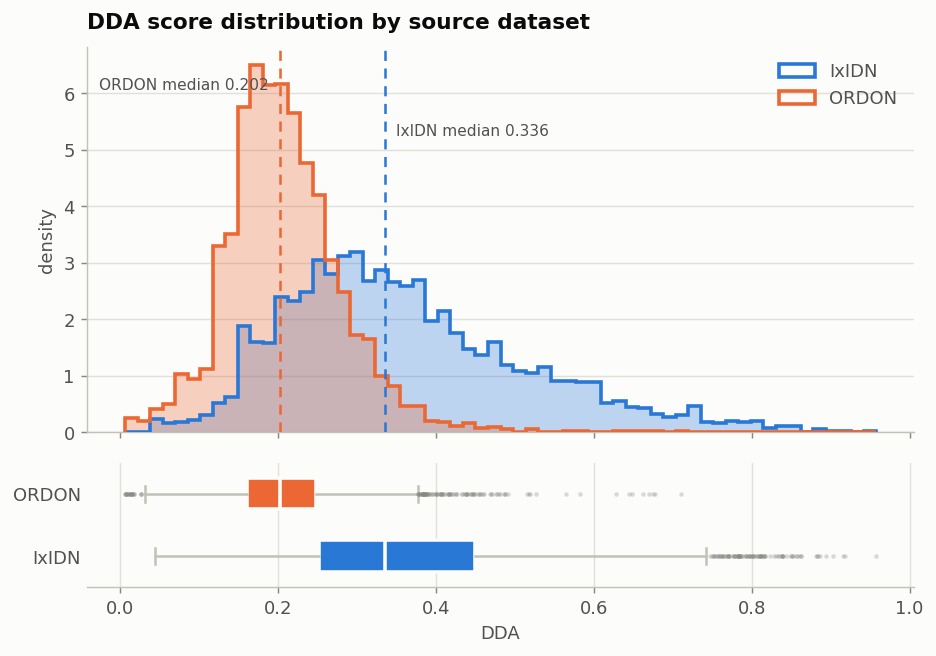

In [10]:
# Histogram (density, so the slightly unequal group sizes don't bias the shapes)
# stacked over a boxplot sharing the same DDA axis, so both read as one figure.
lo, hi = min(pos.min(), neg.min()), max(pos.max(), neg.max())
bins = np.linspace(lo, hi, 61)

fig, (ax_h, ax_b) = plt.subplots(
    2, 1, figsize=(8.2, 5.4), sharex=True,
    gridspec_kw={"height_ratios": [3.1, 1], "hspace": 0.12},
)

for data, color, label in [(pos, C_IX, "IxIDN"), (neg, C_OR, "ORDON")]:
    ax_h.hist(data, bins=bins, density=True, color=color, alpha=0.30, zorder=2)
    ax_h.hist(data, bins=bins, density=True, histtype="step",
              color=color, linewidth=2, label=label, zorder=3)

ax_h.set_title("DDA score distribution by source dataset")
ax_h.set_ylabel("density")
ax_h.grid(axis="y", zorder=0)
ax_h.set_axisbelow(True)
ax_h.legend(loc="upper right", labelcolor=INK2)

# Median rules with direct labels — placed on opposite sides and staggered
# vertically so the two never collide. (ORDON's median is left of IxIDN's.)
top = ax_h.get_ylim()[1]
placement = [
    (neg, C_OR, "ORDON", "right", (-6, 0), 0.90),
    (pos, C_IX, "IxIDN", "left", (6, 0), 0.78),
]
for data, color, label, ha, off, y_frac in placement:
    med = np.median(data)
    ax_h.axvline(med, color=color, linewidth=1.4, linestyle=(0, (4, 3)), zorder=4)
    ax_h.annotate(f"{label} median {med:.3f}", (med, top * y_frac),
                  xytext=off, textcoords="offset points",
                  ha=ha, va="center", fontsize=8.5, color=INK2, zorder=5)

bp = ax_b.boxplot(
    [pos, neg], vert=False, widths=0.5, patch_artist=True,
    flierprops={"marker": "o", "markersize": 2.5, "markerfacecolor": MUTED,
                "markeredgecolor": "none", "alpha": 0.30},
    medianprops={"color": SURFACE, "linewidth": 2},
    whiskerprops={"color": BASELINE, "linewidth": 1.4},
    capprops={"color": BASELINE, "linewidth": 1.4},
)
for patch, color in zip(bp["boxes"], [C_IX, C_OR]):
    patch.set(facecolor=color, edgecolor=SURFACE, linewidth=2)  # 2px surface ring

ax_b.set_yticks([1, 2], ["IxIDN", "ORDON"])
ax_b.set_xlabel("DDA")
ax_b.grid(axis="x", zorder=0)
ax_b.set_axisbelow(True)
ax_b.spines["left"].set_visible(False)
ax_b.tick_params(axis="y", length=0)

plt.savefig(OUT / f"dda_distribution_{Path(MERGED_FILE).stem}.png", bbox_inches="tight")
plt.show()

## 7. ROC — can DDA separate IxIDN from ORDON?

**IxIDN = positive class, ORDON = negative class**, DDA used directly as the score.

This measures how well the DDA score ranks IxIDN pairs above ORDON pairs. AUC 0.5 is chance;
below 0.5 means the score is *anti*-correlated with the IxIDN label (i.e. it separates the two
groups, just in the opposite direction).

AUC                     : 0.8272
positives (IxIDN)       : 5,334
negatives (ORDON)       : 4,998
best threshold (Youden) : DDA >= 0.2745
  TPR (sensitivity)     : 0.683
  FPR                   : 0.154  (specificity 0.846)


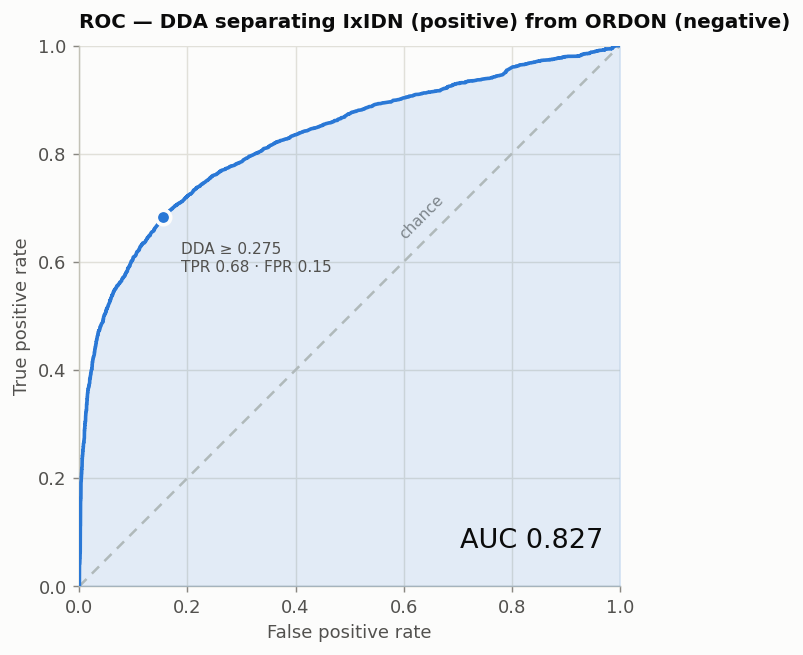

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve

y_true = np.r_[np.ones(len(pos), dtype=int), np.zeros(len(neg), dtype=int)]
y_score = np.r_[pos, neg]

fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

# Youden's J — the threshold maximising (sensitivity + specificity - 1)
j = np.argmax(tpr - fpr)
print(f"AUC                     : {auc:.4f}")
print(f"positives (IxIDN)       : {len(pos):,}")
print(f"negatives (ORDON)       : {len(neg):,}")
print(f"best threshold (Youden) : DDA >= {thresholds[j]:.4f}")
print(f"  TPR (sensitivity)     : {tpr[j]:.3f}")
print(f"  FPR                   : {fpr[j]:.3f}  (specificity {1 - fpr[j]:.3f})")

fig, ax = plt.subplots(figsize=(5.4, 5.4))

ax.plot([0, 1], [0, 1], color=BASELINE, linewidth=1.4,
        linestyle=(0, (4, 3)), zorder=2)
ax.annotate("chance", (0.62, 0.62), xytext=(-4, 5), textcoords="offset points",
            rotation=45, rotation_mode="anchor", fontsize=8.5, color=MUTED,
            ha="left", va="bottom")

ax.fill_between(fpr, tpr, color=C_IX, alpha=0.12, zorder=3)
ax.plot(fpr, tpr, color=C_IX, linewidth=2, solid_capstyle="round", zorder=4)

ax.plot(fpr[j], tpr[j], marker="o", markersize=8, color=C_IX,
        markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)
ax.annotate(f"DDA ≥ {thresholds[j]:.3f}\nTPR {tpr[j]:.2f} · FPR {fpr[j]:.2f}",
            (fpr[j], tpr[j]), xytext=(10, -14), textcoords="offset points",
            fontsize=8.5, color=INK2, ha="left", va="top")

ax.annotate(f"AUC {auc:.3f}", (0.97, 0.06), xycoords="axes fraction",
            ha="right", va="bottom", fontsize=15, color=INK)

ax.set_title("ROC — DDA separating IxIDN (positive) from ORDON (negative)", fontsize=11)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(zorder=0)
ax.set_axisbelow(True)

plt.savefig(OUT / f"dda_roc_{Path(MERGED_FILE).stem}.png", bbox_inches="tight")
plt.show()

## 8. Wasserstein distance — violin plot

The 1-Wasserstein (earth-mover) distance between the positive (IxIDN) and negative (ORDON) DDA
distributions. It is measured in **DDA units**: the mean horizontal distance the mass of one
distribution has to travel to match the other.

W₁ is unsigned, so the direction of the shift is reported alongside it. Because the raw value is
scale-dependent, a version normalized by the pooled standard deviation is printed too.

Wasserstein distance W1   : 0.1533 DDA units
  normalized by pooled SD : 1.267
  direction               : IxIDN shifted higher (mean 0.3610 vs 0.2077, Δ +0.1533)


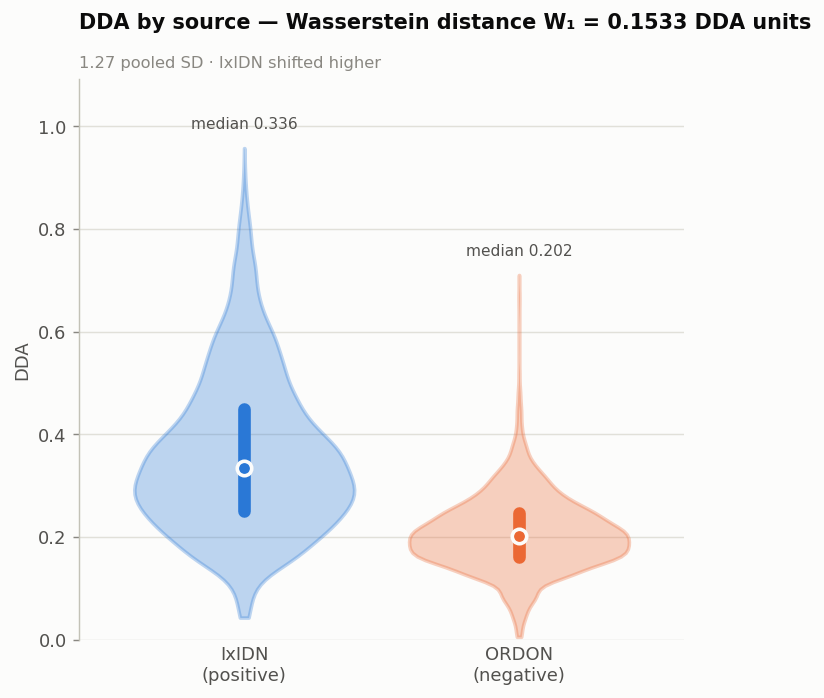

In [12]:
from scipy.stats import wasserstein_distance

w1 = wasserstein_distance(pos, neg)
pooled_sd = np.sqrt(((len(pos) - 1) * pos.var(ddof=1) + (len(neg) - 1) * neg.var(ddof=1))
                    / (len(pos) + len(neg) - 2))
direction = "IxIDN shifted higher" if pos.mean() > neg.mean() else "ORDON shifted higher"

print(f"Wasserstein distance W1   : {w1:.4f} DDA units")
print(f"  normalized by pooled SD : {w1 / pooled_sd:.3f}")
print(f"  direction               : {direction} "
      f"(mean {pos.mean():.4f} vs {neg.mean():.4f}, \u0394 {pos.mean() - neg.mean():+.4f})")

fig, ax = plt.subplots(figsize=(6.0, 5.6))

groups = [("IxIDN", pos, C_IX), ("ORDON", neg, C_OR)]
parts = ax.violinplot([g[1] for g in groups], widths=0.8,
                      showmeans=False, showmedians=False, showextrema=False)

for body, (_, _, color) in zip(parts["bodies"], groups):
    body.set(facecolor=color, edgecolor=color, linewidth=2, zorder=2)
    body.set_alpha(0.30)

# Inner IQR bar + median dot, ringed in the surface color so marks stay separated.
# Median value is labelled above each violin, where nothing can collide with it.
for i, (label, data, color) in enumerate(groups, start=1):
    q1, med, q3 = np.percentile(data, [25, 50, 75])
    iqr_bar = ax.vlines(i, q1, q3, color=color, linewidth=7, zorder=3)
    iqr_bar.set_capstyle("round")
    ax.plot(i, med, marker="o", markersize=8, color=color,
            markeredgecolor=SURFACE, markeredgewidth=2, zorder=4)
    ax.annotate(f"median {med:.3f}", (i, data.max()), xytext=(0, 9),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=8.5, color=INK2, zorder=5)

ax.set_title(f"DDA by source \u2014 Wasserstein distance W\u2081 = {w1:.4f} DDA units",
             fontsize=11.5, pad=28)
ax.annotate(f"{w1 / pooled_sd:.2f} pooled SD \u00b7 {direction}",
            (0, 1.015), xycoords="axes fraction", ha="left", va="bottom",
            fontsize=9, color=MUTED)

ax.set_xticks([1, 2], ["IxIDN\n(positive)", "ORDON\n(negative)"])
ax.set_ylabel("DDA")
ax.set_xlim(0.4, 2.6)
ax.set_ylim(0, max(pos.max(), neg.max()) * 1.14)
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="x", length=0)

plt.savefig(OUT / f"dda_violin_{Path(MERGED_FILE).stem}.png", bbox_inches="tight")
plt.show()